# Preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler,LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, SequentialFeatureSelector, RFE
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
TRAIN_PATH = "../datasets/row_dataset/KDDTrain+_20Percent.txt"
TEST_PATH  = "../datasets/row_dataset/KDDTest+.txt"

COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack_class", "num_learners",
]

# Columns that are always zero / redundant in NSL-KDD
DROP_COLS = ["num_outbound_cmds", "num_learners"]

CAT_COLS = ["protocol_type", "service", "flag"]
label = 0
# Unified attack-group mapping (single source of truth)
ATTACK_GROUP = {
    # Probe
    "ipsweep": "Probe", "satan": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "saint": "Probe", "mscan": "Probe",
    # DoS
    "teardrop": "DoS", "pod": "DoS", "land": "DoS", "back": "DoS",
    "neptune": "DoS", "smurf": "DoS", "mailbomb": "DoS", "udpstorm": "DoS",
    "apache2": "DoS", "processtable": "DoS",
    # U2R
    "perl": "U2R", "loadmodule": "U2R", "rootkit": "U2R", "buffer_overflow": "U2R",
    "xterm": "U2R", "ps": "U2R", "sqlattack": "U2R", "httptunnel": "U2R",
    # R2L
    "ftp_write": "R2L", "phf": "R2L", "guess_passwd": "R2L", "warezmaster": "R2L",
    "warezclient": "R2L", "imap": "R2L", "spy": "R2L", "multihop": "R2L",
    "named": "R2L", "snmpguess": "R2L", "worm": "R2L", "snmpgetattack": "R2L",
    "xsnoop": "R2L", "xlock": "R2L", "sendmail": "R2L",
    # Normal
    "normal": "Normal",
}

In [3]:
def load_nslkdd(train_path: str = TRAIN_PATH, test_path: str = TEST_PATH):
    """Load NSL-KDD train/test CSVs, drop redundant columns, and return raw DataFrames."""
    train_df = pd.read_csv(train_path, names=COLUMNS)
    test_df  = pd.read_csv(test_path,  names=COLUMNS)

    train_df.drop(columns=DROP_COLS, inplace=True)
    test_df.drop(columns=DROP_COLS,  inplace=True)

    print(f"Train shape : {train_df.shape}")
    print(f"Test  shape : {test_df.shape}")
    return train_df, test_df


In [4]:
df_train, df_test = load_nslkdd()

Train shape : (25192, 41)
Test  shape : (22544, 41)


In [5]:
print(f"The null values in the training dataset:\n{df_train.isna().sum()}")

The null values in the training dataset:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
sr

In [6]:
print(f"The duplicated values in the training set: {df_train.duplicated().sum()}")
print(f"The duplicated values in the testing set: {df_test.duplicated().sum()}")

df_train.drop_duplicates(inplace= True)
df_test.drop_duplicates(inplace= True)

df_train.reset_index(inplace= True, drop= True)
df_test.reset_index(inplace= True, drop= True)

print(f"\ndropping duplicated values: \n")
print(f"The duplicated values in the training set: {df_train.duplicated().sum()}")
print(f"The duplicated values in the testing set: {df_test.duplicated().sum()}")

The duplicated values in the training set: 0
The duplicated values in the testing set: 0

dropping duplicated values: 

The duplicated values in the training set: 0
The duplicated values in the testing set: 0


In [7]:
print(f"The null values in the testing dataset:\n{df_test.isna().sum()}")

The null values in the testing dataset:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv

In [8]:
def label_data(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    1.Map raw attack labels to 5 groups, then encode them numerically.
    2.Apply label encoder to the target variable.

    Returns X_train, y_train, X_test, y_test, and the fitted LabelEncoder.
    """

    for df, name in [(train_df, "train"), (test_df, "test")]:
        unknown = set(df["attack_class"].unique()) - set(ATTACK_GROUP.keys())
        if unknown:
            raise ValueError(f"unmapped attack types:{unknown}")

    train_df_copy = train_df.copy()
    test_df_copy  = test_df.copy()

    train_df_copy["attack_group"] = train_df_copy["attack_class"].map(ATTACK_GROUP)
    test_df_copy["attack_group"]  = test_df_copy["attack_class"].map(ATTACK_GROUP)

    # Encode labels
    le = LabelEncoder()
    y_train_copy = le.fit_transform(train_df_copy["attack_group"])
    y_test_copy  = le.transform(test_df_copy["attack_group"])

    print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

    # Drop label columns to get feature matrices
    X_train_copy = train_df_copy.drop(columns=["attack_class", "attack_group"])
    X_test_copy  = test_df_copy.drop(columns=["attack_class",  "attack_group"])

    # Wrap labels as Series for convenience
    y_train_copy = pd.Series(y_train_copy, name="attack", index=X_train_copy.index)
    y_test_copy  = pd.Series(y_test_copy,  name="attack", index=X_test_copy.index)

    return X_train_copy, y_train_copy, X_test_copy, y_test_copy, le
X_train, y_train_labeled, X_test, y_test_labeled, label_encoder = label_data(df_train, df_test)

Label mapping: {'DoS': 0, 'Normal': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}


In [9]:
column_num = X_train.select_dtypes(include= ['int64', 'float64']).columns.tolist()
column_obj = X_train.select_dtypes(include= 'object').columns.tolist()

print(f"The numerical features in the dataset: {len(column_num)}")
print(f"The categorical features in the dataset: {len(column_obj)}")
print("=" * 80, '\n')
print(f"The dimensionality of original set training: {df_train.shape}, testing: {df_test.shape}, id of training: {id(df_train)}")
print(f"The shape model feature training: {X_train.shape}, testing: {X_test.shape}, id of testing: {id(X_train)}")

The numerical features in the dataset: 37
The categorical features in the dataset: 3

The dimensionality of original set training: (25192, 41), testing: (22544, 41), id of training: 2042305621536
The shape model feature training: (25192, 40), testing: (22544, 40), id of testing: 2042305275216


In [10]:
pipeline_transformer = ColumnTransformer(
    transformers=[
        (
            'Categorical_transformer',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            column_obj
        ),
        (
            'Numerical_transformer',
            MinMaxScaler(),
            column_num
        )
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

X_train_preprocessed = pipeline_transformer.fit_transform(X_train)
X_train_preprocessed = pd.DataFrame(
    data=X_train_preprocessed,
    columns=pipeline_transformer.get_feature_names_out(),
    index=X_train.index
)

X_test_preprocessed = pipeline_transformer.transform(X_test)
X_test_preprocessed = pd.DataFrame(
    data=X_test_preprocessed,
    columns=pipeline_transformer.get_feature_names_out(),
    index=X_test.index
)

print(f"The shape of the preprocessed training set: {X_train_preprocessed.shape}")
print(f"The shape of the preprocessed testing set: {X_test_preprocessed.shape}")

The shape of the preprocessed training set: (25192, 117)
The shape of the preprocessed testing set: (22544, 117)


In [11]:
df_train_preprocessed = pd.concat([X_train_preprocessed, y_train_labeled], axis= 1)
df_test_preprocessed = pd.concat([X_test_preprocessed, y_test_labeled], axis= 1)

print(f"The shape of the organ train dataset: {df_train_preprocessed.shape}")
print('=' * 50)
print(f"The shape of the test organ dataset: {df_test_preprocessed.shape}")

df_train_preprocessed.to_csv(r'../datasets/preprocessed/KDD_train_preprocessed.csv', index= False)
df_test_preprocessed.to_csv(r'../datasets/preprocessed/KDD_test_preprocessed.csv', index= False)

The shape of the organ train dataset: (25192, 118)
The shape of the test organ dataset: (22544, 118)


# Filtering method

## Chi2 selection

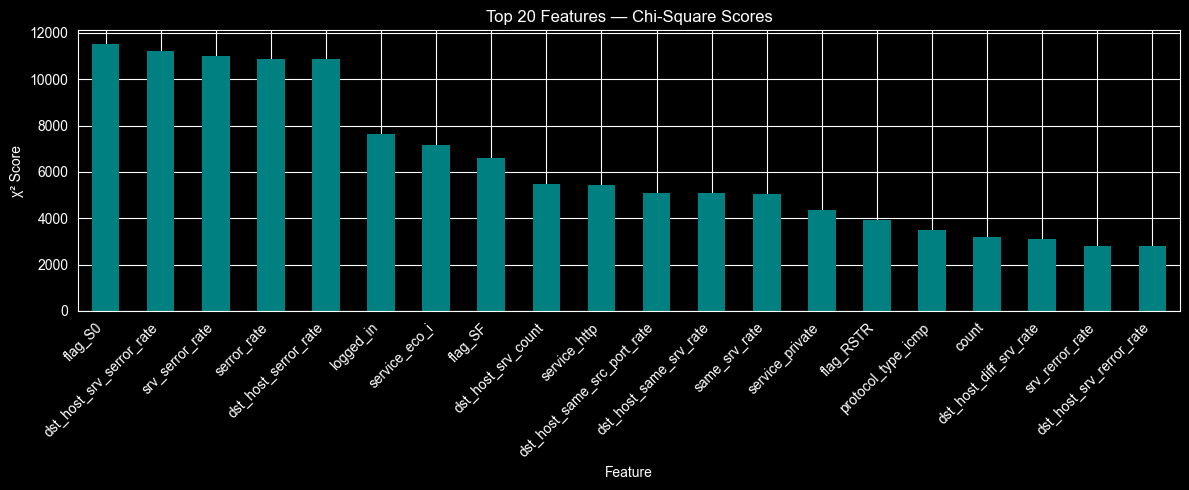

Top 20 features selected by Chi-Square test:
['flag_S0', 'dst_host_srv_serror_rate', 'srv_serror_rate', 'serror_rate', 'dst_host_serror_rate', 'logged_in', 'service_eco_i', 'flag_SF', 'dst_host_srv_count', 'service_http', 'dst_host_same_src_port_rate', 'dst_host_same_srv_rate', 'same_srv_rate', 'service_private', 'flag_RSTR', 'protocol_type_icmp', 'count', 'dst_host_diff_srv_rate', 'srv_rerror_rate', 'dst_host_srv_rerror_rate']


In [12]:
k = 20
def select_k_best_test(data : pd.DataFrame, target : pd.Series, k : int = k, score_function : object = chi2, visualizing : bool = True) -> list:
    kbest_selector = SelectKBest(score_func= score_function, k = k) # type: ignore
    kbest_selector.fit(data, target)

    kbest_scores = pd.Series(kbest_selector.scores_, index=data.columns)
    kbest_scores_sorted = kbest_scores.sort_values(ascending=False)
    selected_features_kbest = kbest_scores_sorted.head(k).index.tolist()

    if visualizing:
        plt.figure(figsize=(12, 5))
        kbest_scores_sorted.head(k).plot(kind='bar', color='teal', edgecolor='none')
        plt.title(f'Top {k} Features — Chi-Square Scores')
        plt.xlabel('Feature')
        plt.ylabel('χ² Score')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    return selected_features_kbest

chi2_selected_feature = select_k_best_test(data= X_train_preprocessed, target= y_train_labeled, k= k, score_function= chi2, visualizing= True)

print(f"Top {k} features selected by Chi-Square test:")
print(chi2_selected_feature)

## Mutual Info selection

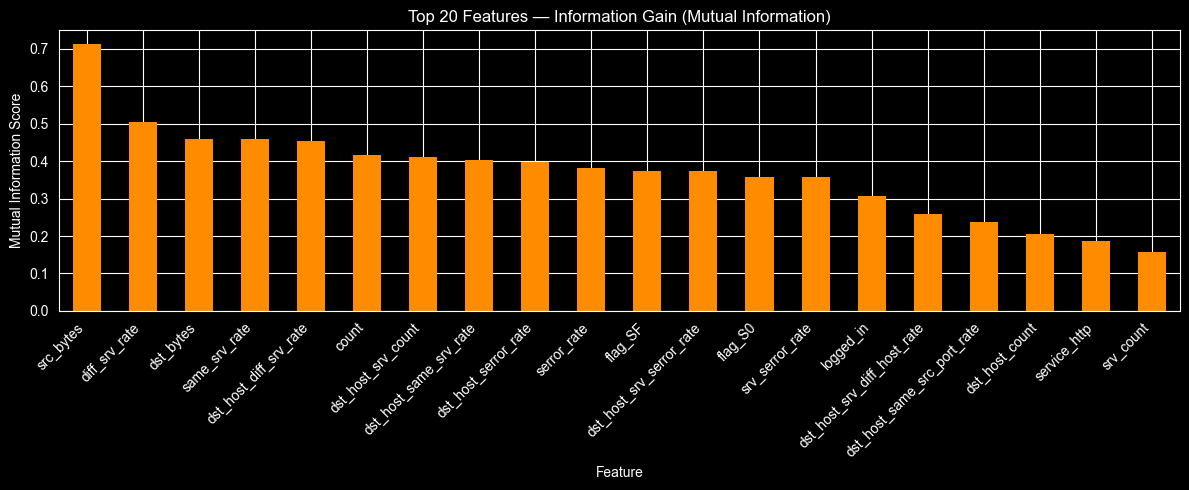

Top 20 features by Information Gain (Mutual Information):
['src_bytes', 'diff_srv_rate', 'dst_bytes', 'same_srv_rate', 'dst_host_diff_srv_rate', 'count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'serror_rate', 'flag_SF', 'dst_host_srv_serror_rate', 'flag_S0', 'srv_serror_rate', 'logged_in', 'dst_host_srv_diff_host_rate', 'dst_host_same_src_port_rate', 'dst_host_count', 'service_http', 'srv_count']


In [13]:
def mutual_info_test(feature : pd.DataFrame, target : pd.Series, k : int = 10, visualizing : bool = True) -> list:

    mi_score = mutual_info_classif(feature, target, random_state= 42)
    mi_score = pd.Series(mi_score, index= feature.columns)
    mi_score = mi_score.sort_values(ascending= False)

    mi_top_features = mi_score.head(k).index.tolist()

    if visualizing:
        plt.figure(figsize=(12, 5))
        mi_score.head(k).plot(kind='bar', color='darkorange', edgecolor='none')
        plt.title(f'Top {k} Features — Information Gain (Mutual Information)')
        plt.xlabel('Feature')
        plt.ylabel('Mutual Information Score')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    return mi_top_features

k_mi = 20
selected_features_mi = mutual_info_test(feature= X_train_preprocessed, target= y_train_labeled, k = k_mi, visualizing= True)

print(f"Top {k_mi} features by Information Gain (Mutual Information):")
print(selected_features_mi)

In [14]:
X_train_chi2 = X_train_preprocessed[chi2_selected_feature].copy()
X_train_mi = X_train_preprocessed[selected_features_mi].copy()

X_test_chi2 = X_test_preprocessed[chi2_selected_feature].copy()
X_test_mi = X_test_preprocessed[selected_features_mi].copy()

print(f"The shape of the train dataset after chi2: {X_train_chi2.shape}")
print(f"The shape of the train dataset after mutual info: {X_train_mi.shape}")
print('=' * 50)
print(f"The shape of the test dataset after chi2: {X_test_chi2.shape}")
print(f"The shape of the test dataset after mutual info: {X_test_mi.shape}")

The shape of the train dataset after chi2: (25192, 20)
The shape of the train dataset after mutual info: (25192, 20)
The shape of the test dataset after chi2: (22544, 20)
The shape of the test dataset after mutual info: (22544, 20)


In [15]:
df_train_chi2 = pd.concat([X_train_chi2, y_train_labeled], axis= 1)
df_train_mi = pd.concat([X_train_mi, y_train_labeled], axis= 1)

df_test_chi2 = pd.concat([X_test_chi2, y_test_labeled], axis= 1)
df_test_mi = pd.concat([X_test_mi, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after chi2: {df_train_chi2.shape}")
print(f"The shape of the train dataset after mutual info: {df_train_mi.shape}")
print('=' * 50)
print(f"The shape of the test dataset after chi2: {df_test_chi2.shape}")
print(f"The shape of the test dataset after mutual info: {df_test_mi.shape}")

df_train_chi2.to_csv(r'../datasets/filtered/KDD_train_chi2.csv', index= False)
df_train_mi.to_csv(r'../datasets/filtered/KDD_train_mi.csv', index= False)

df_test_chi2.to_csv(r'../datasets/filtered/KDD_test_chi2.csv', index= False)
df_test_mi.to_csv(r'../datasets/filtered/KDD_test_mi.csv', index= False)

The shape of the train dataset after chi2: (25192, 21)
The shape of the train dataset after mutual info: (25192, 21)
The shape of the test dataset after chi2: (22544, 21)
The shape of the test dataset after mutual info: (22544, 21)


# Wrapper methods

## RFE on Random Forest

In [16]:
rfe_forest = RFE(
    estimator=RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1,
        random_state=42
    ),

    n_features_to_select=20,
    step=10
)

X_train_rfe_forest = rfe_forest.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[rfe_forest.get_support()]
X_train_rfe_forest = pd.DataFrame(data=X_train_rfe_forest, columns=selected_features)

X_test_rfe_forest = rfe_forest.transform(X_test_preprocessed)
X_test_rfe_forest = pd.DataFrame(data=X_test_rfe_forest, columns=selected_features)

print(f"The shape of the feature after RFE (train): {X_train_rfe_forest.shape}")
print(f"The selected feature in the RFE (train): {X_train_rfe_forest.columns}")

print('=' * 50)

print(f"The shape of the feature after RFE (test): {X_test_rfe_forest.shape}")
print(f"The selected feature in the RFE (test): {X_test_rfe_forest.columns}")

The shape of the feature after RFE (train): (25192, 20)
The selected feature in the RFE (train): Index(['protocol_type_icmp', 'service_private', 'flag_S0', 'flag_SF',
       'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate'],
      dtype='object')
The shape of the feature after RFE (test): (22544, 20)
The selected feature in the RFE (test): Index(['protocol_type_icmp', 'service_private', 'flag_S0', 'flag_SF',
       'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_ho

In [17]:
df_train_rfe_forest = pd.concat([X_train_rfe_forest, y_train_labeled], axis= 1)
df_test_rfe_forest = pd.concat([X_test_rfe_forest, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after RFE (Random Forest): {df_train_rfe_forest.shape}")
print('=' * 50)
print(f"The shape of the test dataset after RFE (Random Forest): {df_test_rfe_forest.shape}")

df_train_rfe_forest.to_csv(r'../datasets/wrappered/KDD_train_rfe_forest.csv', index= False)
df_test_rfe_forest.to_csv(r'../datasets/wrappered/KDD_test_rfe_forest.csv', index= False)

The shape of the train dataset after RFE (Random Forest): (25192, 21)
The shape of the test dataset after RFE (Random Forest): (22544, 21)


## RFE on SVC

In [18]:
rfe_svc = RFE(
    estimator=SVC(
        kernel='linear',
        C=10,
        cache_size=1000,
        random_state=42
    ),

    n_features_to_select=20,
    step=10
)

X_train_rfe_svc = rfe_svc.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[rfe_svc.get_support()]
X_train_rfe_svc = pd.DataFrame(data=X_train_rfe_svc, columns=selected_features)

X_test_rfe_svc = rfe_svc.transform(X_test_preprocessed)
X_test_rfe_svc = pd.DataFrame(data=X_test_rfe_svc, columns=selected_features)

print(f"The shape of the feature after RFE (train) on SVC: {X_train_rfe_svc.shape}")
print(f"The selected feature in the RFE (train) on SVC: {X_train_rfe_svc.columns}")

print('=' * 50)

print(f"The shape of the feature after RFE (test) on SVC: {X_test_rfe_svc.shape}")
print(f"The selected feature in the RFE (test) on SVC: {X_test_rfe_svc.columns}")

The shape of the feature after RFE (train) on SVC: (25192, 20)
The selected feature in the RFE (train) on SVC: Index(['protocol_type_icmp', 'protocol_type_udp', 'service_http',
       'service_other', 'flag_RSTO', 'duration', 'wrong_fragment', 'hot',
       'root_shell', 'num_file_creations', 'num_access_files',
       'is_guest_login', 'count', 'srv_rerror_rate', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_rerror_rate'],
      dtype='object')
The shape of the feature after RFE (test) on SVC: (22544, 20)
The selected feature in the RFE (test) on SVC: Index(['protocol_type_icmp', 'protocol_type_udp', 'service_http',
       'service_other', 'flag_RSTO', 'duration', 'wrong_fragment', 'hot',
       'root_shell', 'num_file_creations', 'num_access_files',
       'is_guest_login', 'count', 'srv_rerror_rate', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'ds

In [19]:
df_train_rfe_svc = pd.concat([X_train_rfe_svc, y_train_labeled], axis= 1)
df_test_rfe_svc = pd.concat([X_test_rfe_svc, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after RFE for SVC: {df_train_rfe_svc.shape}")
print('=' * 50)
print(f"The shape of the test dataset after RFE for SVC: {df_test_rfe_svc.shape}")

df_train_rfe_svc.to_csv(r'../datasets/wrappered/KDD_train_rfe_svc.csv', index= False)
df_test_rfe_svc.to_csv(r'../datasets/wrappered/KDD_test_rfe_svc.csv', index= False)

The shape of the train dataset after RFE for SVC: (25192, 21)
The shape of the test dataset after RFE for SVC: (22544, 21)


## RFE on XGBoost

In [20]:
rfe_xgboost = RFE(
    estimator=XGBClassifier(
        n_estimators=50,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42
    ),

    n_features_to_select=20,
    step=10
)

X_train_rfe_xgboost = rfe_xgboost.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[rfe_xgboost.get_support()]
X_train_rfe_xgboost = pd.DataFrame(data=X_train_rfe_xgboost, columns=selected_features)

X_test_rfe_xgboost = rfe_xgboost.transform(X_test_preprocessed)
X_test_rfe_xgboost = pd.DataFrame(data=X_test_rfe_xgboost, columns=selected_features)

print(f"The shape of the feature after RFE (train) on XGBoost: {X_train_rfe_xgboost.shape}")
print(f"The selected feature in the RFE (train) on XGBoost: {X_train_rfe_xgboost.columns}")

print('=' * 50)

print(f"The shape of the feature after RFE (test) on XGBoost: {X_test_rfe_xgboost.shape}")
print(f"The selected feature in the RFE (test) on XGBoost: {X_test_rfe_xgboost.columns}")

The shape of the feature after RFE (train) on XGBoost: (25192, 20)
The selected feature in the RFE (train) on XGBoost: Index(['protocol_type_tcp', 'service_eco_i', 'service_ecr_i', 'service_http',
       'service_private', 'flag_S0', 'flag_SF', 'src_bytes', 'dst_bytes',
       'wrong_fragment', 'logged_in', 'count', 'serror_rate', 'same_srv_rate',
       'diff_srv_rate', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_serror_rate',
       'dst_host_rerror_rate'],
      dtype='object')
The shape of the feature after RFE (test) on XGBoost: (22544, 20)
The selected feature in the RFE (test) on XGBoost: Index(['protocol_type_tcp', 'service_eco_i', 'service_ecr_i', 'service_http',
       'service_private', 'flag_S0', 'flag_SF', 'src_bytes', 'dst_bytes',
       'wrong_fragment', 'logged_in', 'count', 'serror_rate', 'same_srv_rate',
       'diff_srv_rate', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rat

In [21]:
df_train_rfe_xgboost = pd.concat([X_train_rfe_xgboost, y_train_labeled], axis= 1)
df_test_rfe_xgboost = pd.concat([X_test_rfe_xgboost, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after RFE for XGBoost: {df_train_rfe_xgboost.shape}")
print('=' * 50)
print(f"The shape of the test dataset after RFE for XGBoost: {df_test_rfe_xgboost.shape}")

df_train_rfe_xgboost.to_csv(r'../datasets/wrappered/KDD_train_rfe_xgboost.csv', index= False)
df_test_rfe_xgboost.to_csv(r'../datasets/wrappered/KDD_test_rfe_xgboost.csv', index= False)

The shape of the train dataset after RFE for XGBoost: (25192, 21)
The shape of the test dataset after RFE for XGBoost: (22544, 21)


## Sequential Feature Selection with Random Forest

In [ ]:
sfs_forest = SequentialFeatureSelector(
    RandomForestClassifier(
        n_estimators=25,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),

    n_features_to_select=20,
    direction='forward',
    n_jobs=-1,
    cv=2
)

X_train_sfs_forest = sfs_forest.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[sfs_forest.get_support()]
X_train_sfs_forest = pd.DataFrame(data=X_train_sfs_forest, columns=selected_features)

X_test_sfs_forest = sfs_forest.transform(X_test_preprocessed)
X_test_sfs_forest = pd.DataFrame(data=X_test_sfs_forest, columns=selected_features)

print(f"The shape of the feature after SFS (train) for Random Forest: {X_train_sfs_forest.shape}")
print(f"The selected feature in the SFS (train) for Random Forest: {X_train_sfs_forest.columns}")

print('=' * 50)

print(f"The shape of the feature after SFS (test) for Random Forest: {X_test_sfs_forest.shape}")
print(f"The selected feature in the SFS (test) for Random Forest: {X_test_sfs_forest.columns}")

In [ ]:
# saving dataset:
df_train_sfs_forest = pd.concat([X_train_sfs_forest, y_train_labeled], axis= 1)
df_test_sfs_forest = pd.concat([X_test_sfs_forest, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after SFS for Random Forest: {df_train_sfs_forest.shape}")
print('=' * 50)
print(f"The shape of the test dataset after SFS for Random Forest: {df_test_sfs_forest.shape}")

df_train_sfs_forest.to_csv(r'../datasets/wrappered/KDD_train_sfs_forest.csv', index= False)
df_test_sfs_forest.to_csv(r'../datasets/wrappered/KDD_test_sfs_forest.csv', index= False)

## Sequential Feature Selection with SVC

In [ ]:
sfs_svc = SequentialFeatureSelector(
    estimator=SVC(
        kernel='linear',
        C=10,
        tol=1e-2,
        cache_size=1000,
        random_state=42
    ),

    n_features_to_select=20,
    direction='forward',
    scoring='f1_weighted',
    cv=2,
    n_jobs=-1
)

X_train_sfs_svc = sfs_svc.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[sfs_svc.get_support()]
X_train_sfs_svc = pd.DataFrame(data=X_train_sfs_svc, columns=selected_features)

X_test_sfs_svc = sfs_svc.transform(X_test_preprocessed)
X_test_sfs_svc = pd.DataFrame(data=X_test_sfs_svc, columns=selected_features)

print(f"The shape of the feature after SFS (train) on SVC: {X_train_sfs_svc.shape}")
print(f"The selected feature in the SFS (train) on SVC: {X_train_sfs_svc.columns}")

print('=' * 50)

print(f"The shape of the feature after SFS (test) on SVC: {X_test_sfs_svc.shape}")
print(f"The selected feature in the SFS (test) on SVC: {X_test_sfs_svc.columns}")

In [ ]:
# saving dataset:
df_train_sfs_svc = pd.concat([X_train_sfs_svc, y_train_labeled], axis= 1)
df_test_sfs_svc = pd.concat([X_test_sfs_svc, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after SFS for SVC: {df_train_sfs_svc.shape}")
print('=' * 50)
print(f"The shape of the test dataset after SFS for SVC: {df_test_sfs_svc.shape}")

df_train_sfs_svc.to_csv(r'../datasets/wrappered/KDD_train_sfs_svc.csv', index= False)
df_test_sfs_svc.to_csv(r'../datasets/wrappered/KDD_test_sfs_svc.csv', index= False)

## Sequential Feature Selection with XGBoost

In [ ]:
sfs_xgboost = SequentialFeatureSelector(
    estimator=XGBClassifier(
        n_estimators=50,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        gamma=0,
        tree_method='hist',
        eval_metric='mlogloss',
        verbosity=0,
        n_jobs=-1,
        random_state=42
    ),

    n_features_to_select=20,
    direction='forward',
    scoring='f1_weighted',
    cv=2,
    n_jobs=-1
)

X_train_sfs_xgboost = sfs_xgboost.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[sfs_xgboost.get_support()]
X_train_sfs_xgboost = pd.DataFrame(data=X_train_sfs_xgboost, columns=selected_features)

X_test_sfs_xgboost = sfs_xgboost.transform(X_test_preprocessed)
X_test_sfs_xgboost = pd.DataFrame(data=X_test_sfs_xgboost, columns=selected_features)

print(f"The shape of the feature after SFS (train) on XGBoost: {X_train_sfs_xgboost.shape}")
print(f"The selected feature in the SFS (train) on XGBoost: {X_train_sfs_xgboost.columns}")

print('=' * 50)

print(f"The shape of the feature after SFS (test) on XGBoost: {X_test_sfs_xgboost.shape}")
print(f"The selected feature in the SFS (test) on XGBoost: {X_test_sfs_xgboost.columns}")

In [ ]:
# saving dataset:
df_train_sfs_xgboost = pd.concat([X_train_sfs_xgboost, y_train_labeled], axis= 1)
df_test_sfs_xgboost = pd.concat([X_test_sfs_xgboost, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after SFS for XGBoost: {df_train_sfs_xgboost.shape}")
print('=' * 50)
print(f"The shape of the test dataset after SFS for XGBoost: {df_test_sfs_xgboost.shape}")

df_train_sfs_xgboost.to_csv(r'../datasets/wrappered/KDD_train_sfs_xgboost.csv', index= False)
df_test_sfs_xgboost.to_csv(r'../datasets/wrappered/KDD_test_sfs_xgboost.csv', index= False)